# Arc command (G) verification in simulation

Robot starts in the **centre of a 200×200 cm field, pointing NORTH (up)**.
Eight cardinal targets sit ~80 cm out. For each we send the firmware **`G`**
command (robot-relative target `x`=forward, `y`=left) and plot the TRUE path
(`ExactPoseTracker`).

`G` computes the bearing to the target; if it exceeds `turnInPlaceGate` it
**rotates in place** until the target is within the gate, then **pursues** (arcs)
to it. So:
- **N** (dead ahead) → straight line.
- **S** (behind) → ~180° spin, then straight.
- **the rest** → turn and/or arc, depending on the gate.

In [1]:
%matplotlib inline
import os
os.environ["PATH"] = "/opt/homebrew/bin:" + os.environ.get("PATH", "")
import math, subprocess, pathlib, sys
import matplotlib.pyplot as plt
import numpy as np

CWD = pathlib.Path.cwd()
REPO = pathlib.Path.cwd()
while not (REPO / "host_tests").is_dir() and REPO != REPO.parent:
    REPO = REPO.parent
HOST = REPO / "host"
if str(HOST) not in sys.path:
    sys.path.insert(0, str(HOST))
LIB = REPO / "host_tests" / "build"
if not LIB.exists():
    subprocess.run(["cmake", "-S", str(REPO / "host_tests"), "-B", str(LIB)], cwd=REPO, check=True)
print("Building libfirmware_host..."); sys.stdout.flush()
subprocess.run(["cmake", "--build", str(LIB), "--", "-j4"], cwd=REPO, check=True)
print("Build OK")
from robot_radio.io.sim_conn import SimConnection


def run_g(angle_deg, radius_mm=800, speed=200, gate=45, max_ms=14000):
    """Drive G to a target `radius_mm` away at `angle_deg` CCW from forward(north).
    Returns the TRUE path [(x_mm, y_mm), ...] (robot starts at 0,0 heading 0).
    NOTE: the firmware SET key for the turn-in-place threshold is `turnGate`."""
    a = math.radians(angle_deg)
    tx = radius_mm * math.cos(a)   # forward (robot +x)
    ty = radius_mm * math.sin(a)   # left    (robot +y)
    c = SimConnection(); c.connect()
    c.send("SET sTimeout=60000"); c.send(f"SET turnGate={gate}")
    c.set_enc(0.0, 0.0); c.tick(50)
    c.send(f"G {int(round(tx))} {int(round(ty))} {speed}")
    path = []; t = 0
    while t < max_ms:
        lines = c.tick(40); t += 40
        p = c.get_exact_pose(); path.append((p["x"], p["y"]))
        if any("done G" in ln for ln in lines):
            break
    c.disconnect()
    return path


# Plot frame: robot forward (+x sim) = UP (north); left (+y sim) = LEFT.
def to_plot(path):
    xs = [-p[1] / 10.0 for p in path]   # mm->cm, left(+y) -> left
    ys = [ p[0] / 10.0 for p in path]   # forward(+x) -> up
    return xs, ys


# 8 cardinals as angle CCW from forward(N): N=0, W=+90, S=180, E=-90, etc.
DIRS = [("N", 0), ("NE", -45), ("E", -90), ("SE", -135),
        ("S", 180), ("SW", 135), ("W", 90), ("NW", 45)]
R_CM = 80
print("helper ready")

Building libfirmware_host...


[100%] Built target firmware_host
Build OK
helper ready


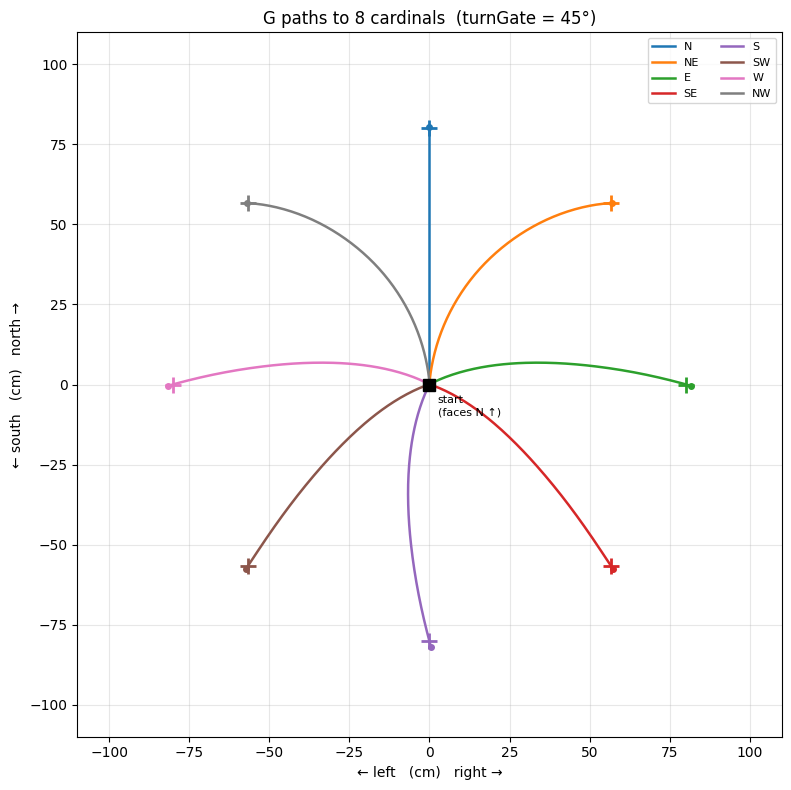

In [2]:
def plot_scenarios(gate, ax):
    for name, ang in DIRS:
        path = run_g(ang, radius_mm=R_CM * 10, gate=gate)
        xs, ys = to_plot(path)
        line, = ax.plot(xs, ys, '-', lw=1.8, label=name)
        # target marker (in plot frame)
        a = math.radians(ang)
        ax.plot(-R_CM * math.sin(a), R_CM * math.cos(a), '+', color=line.get_color(), ms=12, mew=2)
        ax.plot(xs[-1], ys[-1], 'o', color=line.get_color(), ms=4)
    ax.plot(0, 0, 'ks', ms=9)
    ax.annotate('start\n(faces N ↑)', (0, 0), textcoords='offset points', xytext=(6, -22), fontsize=8)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlim(-110, 110); ax.set_ylim(-110, 110)
    ax.set_xlabel('← left   (cm)   right →'); ax.set_ylabel('← south   (cm)   north →')
    ax.set_title(f'G paths to 8 cardinals  (turnGate = {gate}°)')
    ax.legend(fontsize=8, loc='upper right', ncol=2)


fig, ax = plt.subplots(figsize=(8, 8))
plot_scenarios(gate=45, ax=ax)
plt.tight_layout(); plt.show()

Now the same eight scenarios with a **larger gate (100°)** — the robot only spins
in place for targets more than 100° off its nose (the rear ones); the side targets
(E/W/NE/NW) are reached by **arcing** instead of turning first.

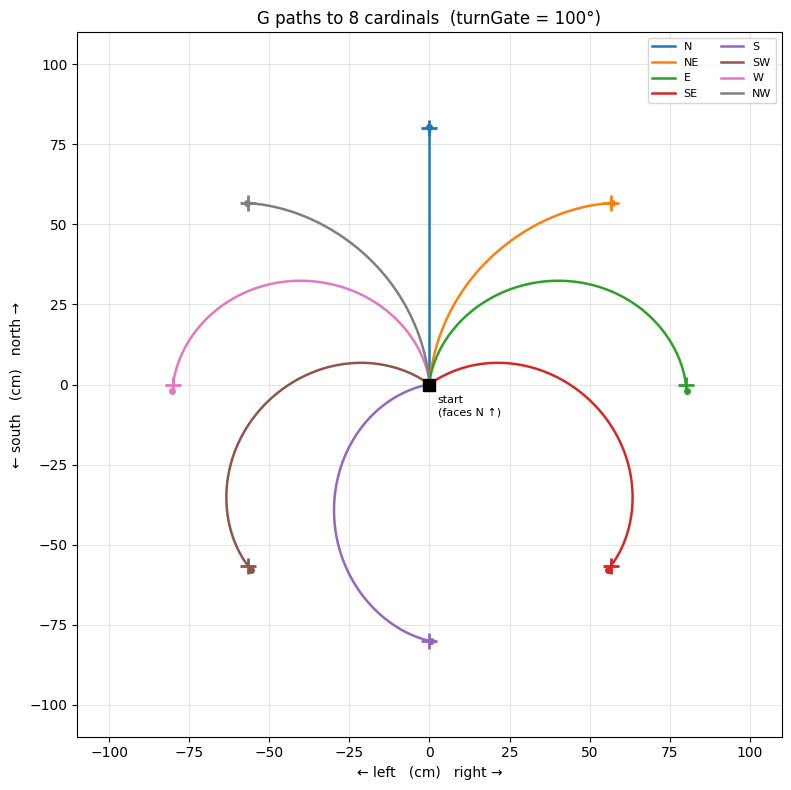

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_scenarios(gate=100, ax=ax)
plt.tight_layout(); plt.show()

## `turnGate = 140°` — arc to the sides, spin only for near-behind targets

At 140° only targets more than 140° off the nose pre-rotate — that's just **S
(180°)**. Everything else (sides at 90°, even the rear-diagonals SE/SW at 135°)
is reached by **arcing**. This keeps the paths smooth and avoids the
directly-behind degeneracy seen at 300°, since S still spins in place first.

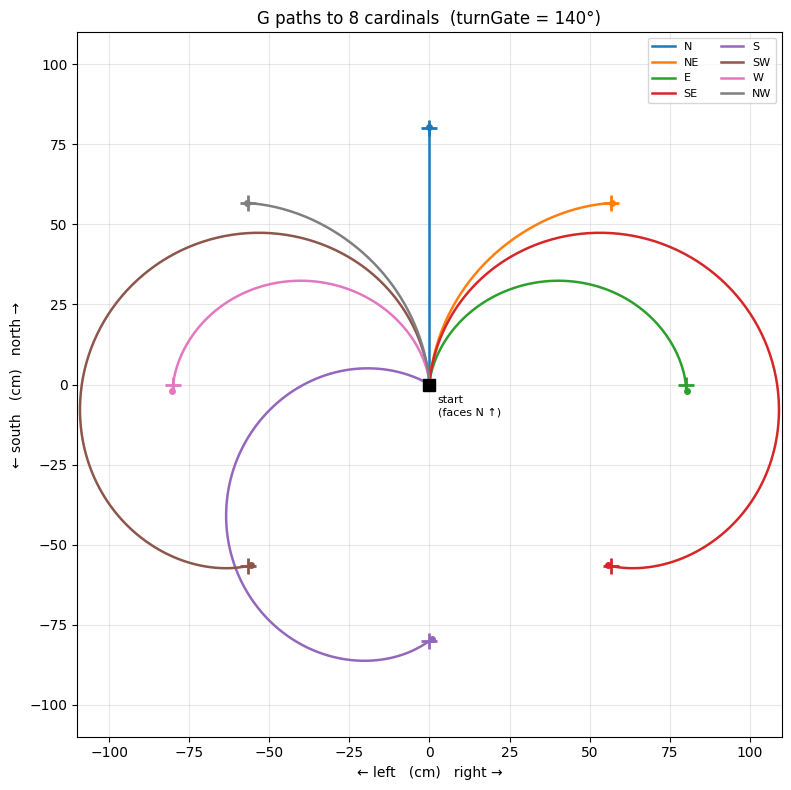

In [4]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_scenarios(gate=140, ax=ax)
plt.tight_layout(); plt.show()